In [485]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

In [486]:
X, y = make_regression(n_samples=4,
                n_features=1,
                n_informative=1,
                n_targets=1,
                noise=80,
                random_state=13
)

In [487]:
# df = pd.DataFrame(
#     data=np.column_stack((X, y)),
#     columns=['X', 'y']
# )

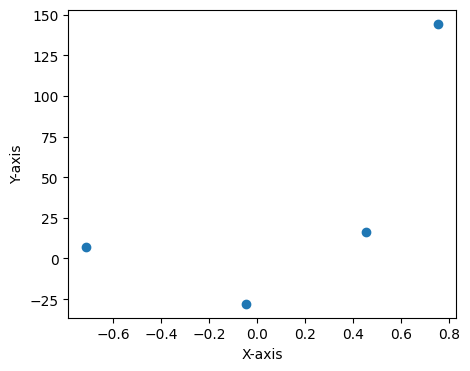

In [488]:
plt.figure(figsize=(5, 4))
plt.scatter(X, y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [489]:
# Let's first apply OLS - Oridinary Least Square
lr_reg = LinearRegression()
lr_reg.fit(X, y)
y_pred = lr_reg.predict(X)

In [490]:
print(lr_reg.coef_) # value of m
print(lr_reg.intercept_) # vlaue of b

[78.35063668]
26.15963284313262


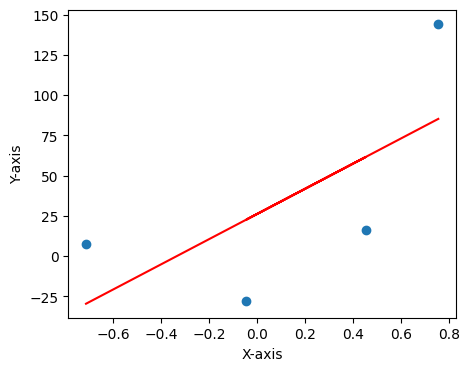

In [491]:
plt.figure(figsize=(5, 4))
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.show()

In [492]:
# Let's apply Gradient Descent assuming the slope is constant (78.35)
# Also let's assume intialy value of incercept is (b = 0)
y_pred_new = ((78.35 * X) + 0).flatten()

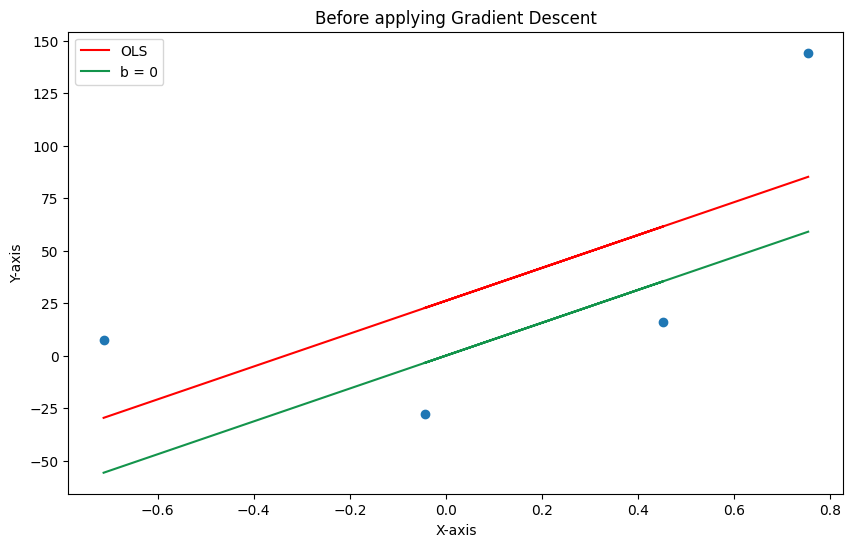

In [493]:
plt.figure(figsize=(10, 6))
plt.plot(X, y_pred, color='red', label='OLS')
plt.plot(X, y_pred_new, color='#13944B', label='b = 0')
plt.title('Before applying Gradient Descent')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.scatter(X, y)
plt.legend()
plt.show()

In [494]:
m, b_old = 78.35, 0

# Iteration 1
loss_slope = -2 * np.sum(y - m * X.ravel() - b_old)
loss_slope

np.float64(-209.27763408209216)

In [495]:
# Let's take learnig rate = 0.1
lr = 0.1

step_size = lr * loss_slope
step_size

np.float64(-20.927763408209216)

In [496]:
# Calculating new step size (b_new)
b_new = b_old - step_size # (b_new = b_old - lr * loss_slope)
b_new

np.float64(20.927763408209216)

In [497]:
y_pred1 = ((m * X) + b_new).flatten()

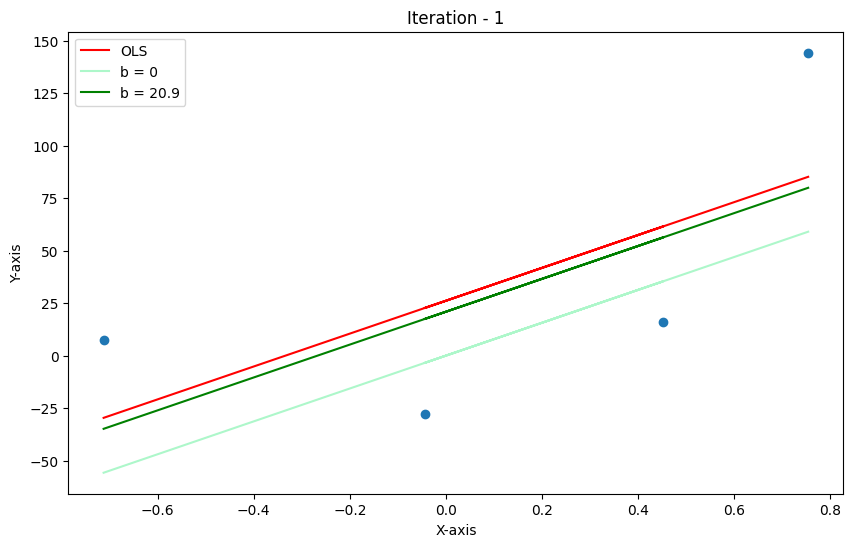

In [498]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.plot(X, y_pred, color='red', label='OLS')
plt.plot(X, y_pred_new, color='#ADF7CA', label='b = 0')
plt.plot(X, y_pred1, color='green', label='b = {:.1f}'.format(b_new))
plt.title('Iteration - 1')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

In [499]:
# Iteration 2
loss_slope = -2 * np.sum(y - m * X.ravel() - b_new)
print(f'new value of slope: {loss_slope}')

step_size = lr * loss_slope
print(f'new step size: {step_size}')

b_new1 = b_new - step_size # (b_new = b_old - lr * loss_slope)
print(f'Updated value of b: {b_new1}')

new value of slope: -41.85552681641845
new step size: -4.185552681641845
Updated value of b: 25.11331608985106


In [500]:
y_pred2 = ((m * X) + b_new1).flatten()

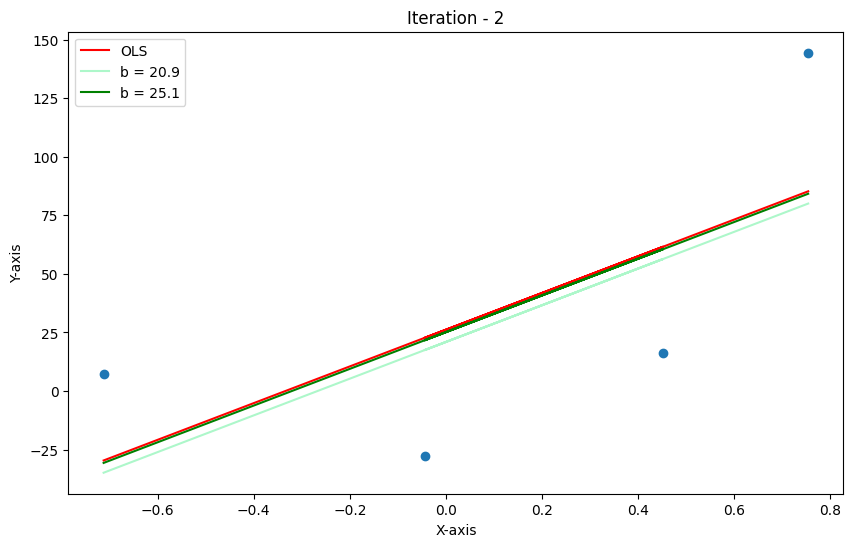

In [501]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.plot(X, y_pred, color='red', label='OLS')
plt.plot(X, y_pred1, color='#ADF7CA', label='b = {:.1f}'.format(b_new))
plt.plot(X, y_pred2, color='green', label='b = {:.1f}'.format(b_new1))
plt.title('Iteration - 2')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

In [502]:
# Iteration 3
loss_slope = -2 * np.sum(y - m * X.ravel() - b_new1)
print(f'new value of slope: {loss_slope}')

step_size = lr * loss_slope
print(f'new step size: {step_size}')

b_new2 = b_new1 - step_size # (b_new = b_old - lr * loss_slope)
print(f'Updated value of b: {b_new2}')

new value of slope: -8.37110536328369
new step size: -0.837110536328369
Updated value of b: 25.95042662617943


In [503]:
y_pred3 = ((m * X) + b_new2).flatten()

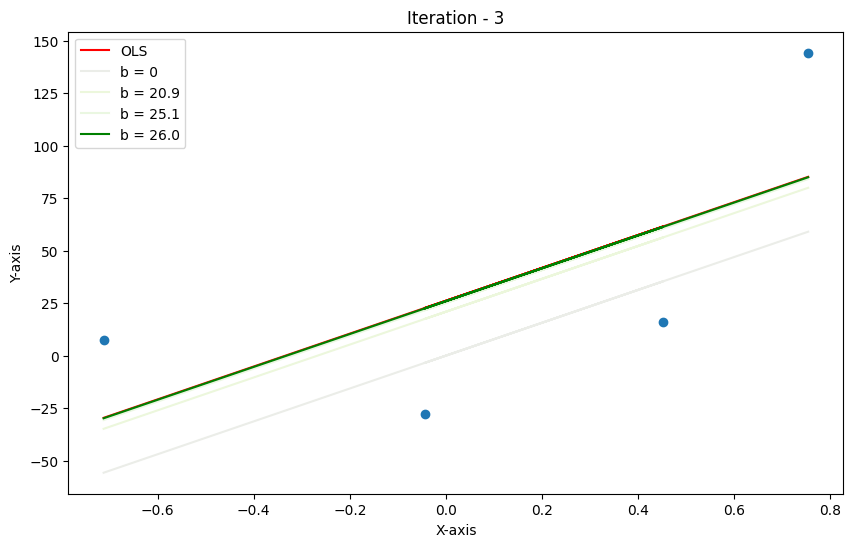

In [504]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.plot(X, y_pred, color='red', label='OLS')
plt.plot(X, y_pred_new, color='#EBEDE8', label='b = 0')
plt.plot(X, y_pred1, color='#ECF7DC', label='b = {:.1f}'.format(b_new))
plt.plot(X, y_pred2, color='#EAF7E1', label='b = {:.1f}'.format(b_new1))
plt.plot(X, y_pred3, color='green', label='b = {:.1f}'.format(b_new2))
plt.title('Iteration - 3')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

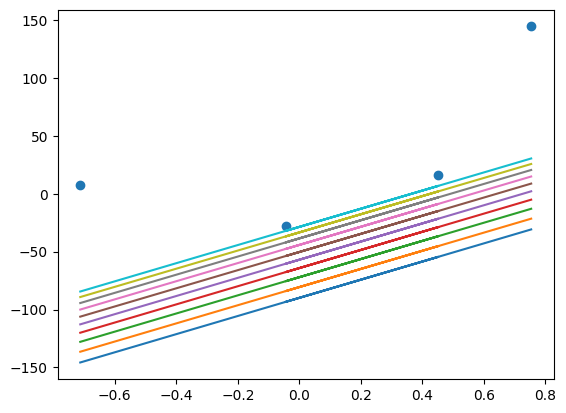

In [508]:
# Doing all the steps in a loop
b, m, lr = -100, 78.35, 0.01

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m * X.ravel() - b) # calcuate loss
    step_size = lr * loss_slope
    b = b - step_size # update b
    y_pred = (m * X + b) # predictions
    plt.plot(X, y_pred)

plt.scatter(X, y)
plt.show()